Part (a): Ground state for V0 = 1
Ground state energy: E0 = -0.308
Expected bound state condition: E₀ should be < 0 for bound state
V0 = 1.0, so bound state energy should be between -V0 and 0
 Ground state is bound (E0 = -0.308 < 0)


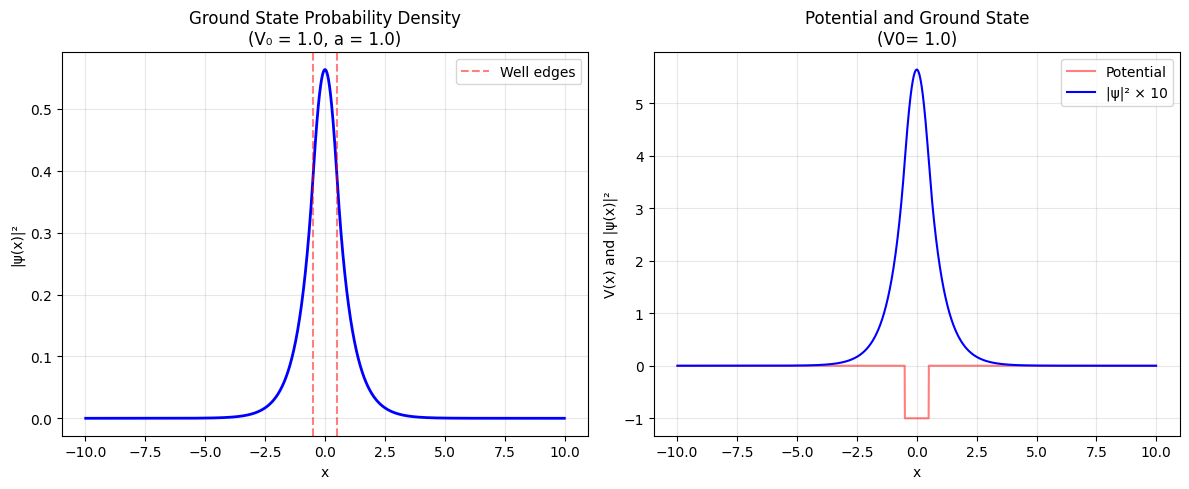

Part (b): Sudden change to V0 = 25
Initial ground state normalization: 1.000000 (should be 1)

Sum of c_n: 1.000000 (should be 1)


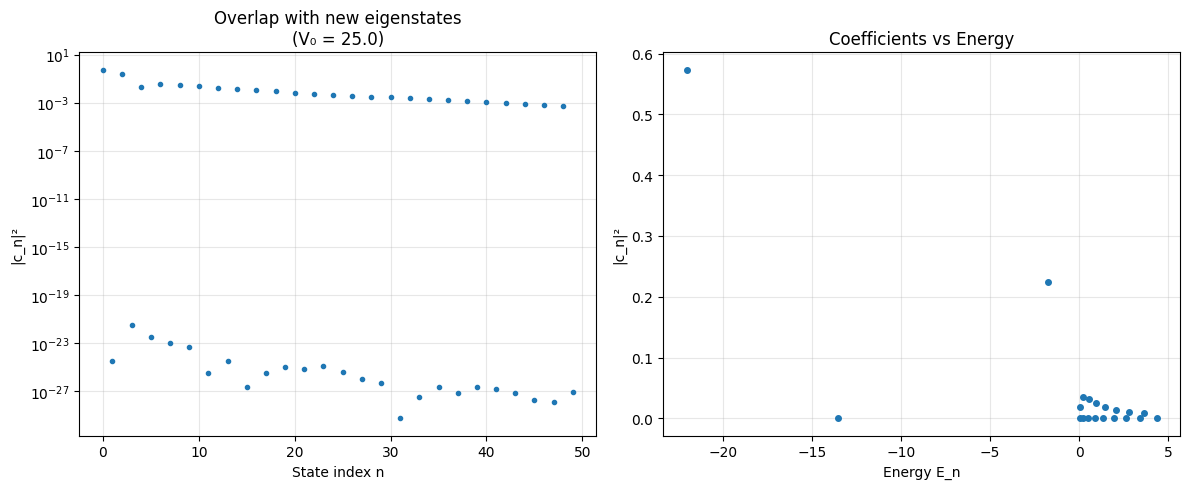


First 10 coefficients:
n	E_n		|c_n|²
----------------------------------------
0	-22.0320	0.573879
1	-13.5237	0.000000
2	-1.7679	0.224005
3	0.0540	0.000000
4	0.0587	0.019353
5	0.2159	0.000000
6	0.2340	0.034364
7	0.4855	0.000000
8	0.5240	0.031530
9	0.8625	0.000000
Time-dependent wavefunction


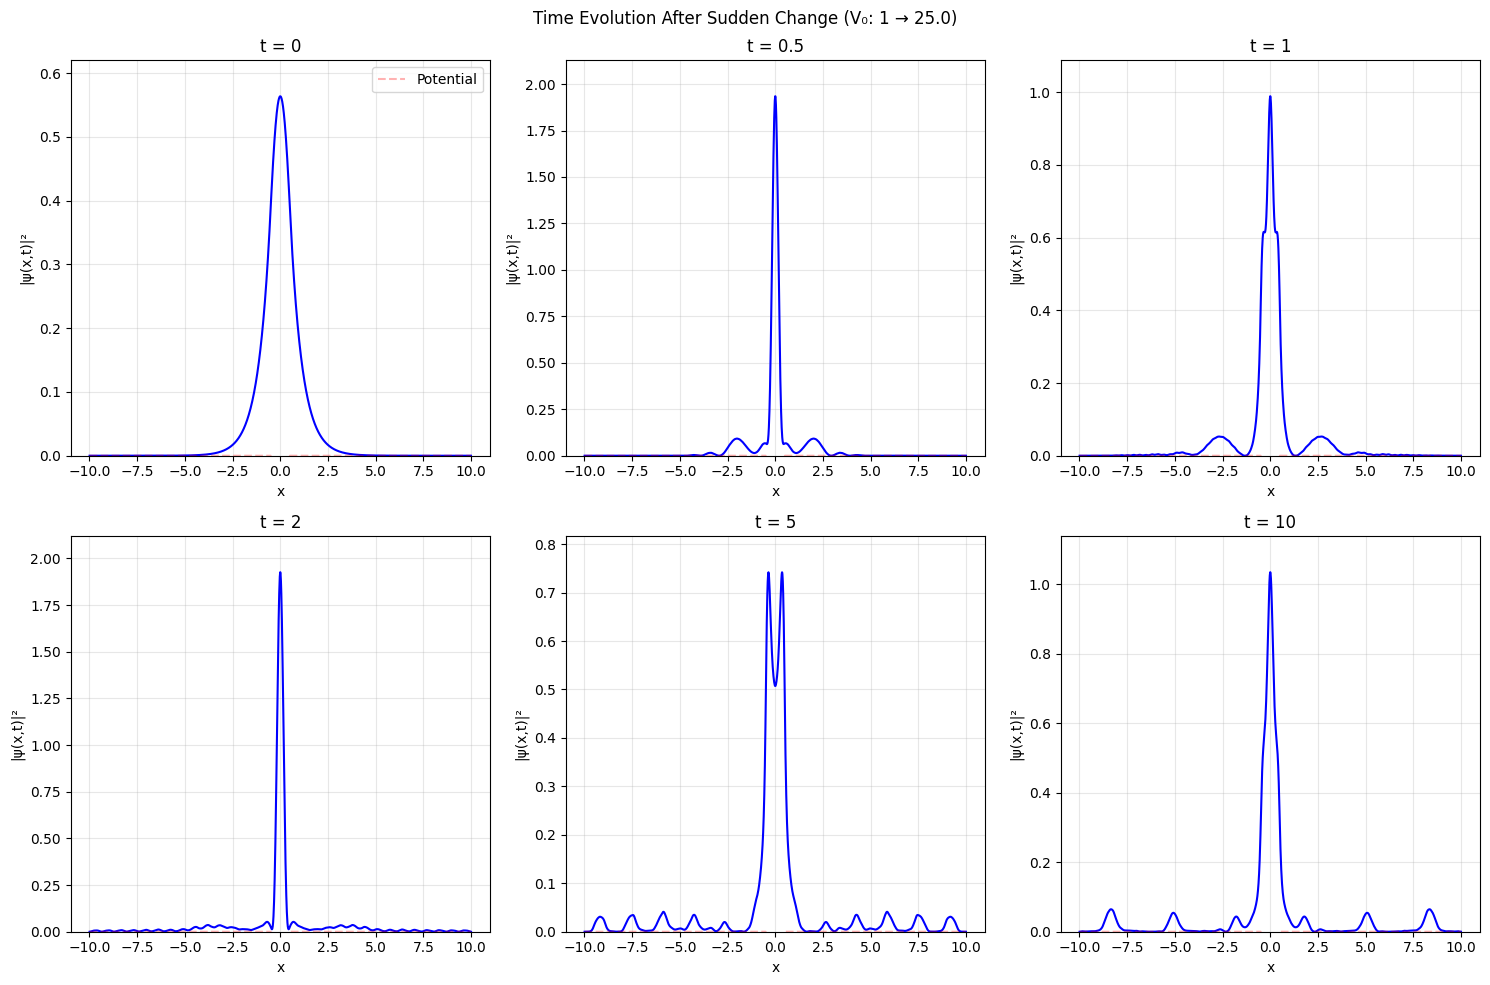

In [10]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Constants
hbar = 1.0
m = 1.0
a = 1.0  # Full width of the well (from -a/2 to a/2)
half_width = a / 2

# Grid parameters
x_min = -10 
x_max = 10
N = 2000  #number of points in the grid

dx = (x_max - x_min) / (N - 1)
N_int = N - 2  # Interior points (excluding boundaries where psi = 0 )
x_int = np.linspace(x_min + dx, x_max - dx, N_int)

def build_hamiltonian(V0, x_int, half_width, dx): # same approch as code in question 1, just defined to be used in part a and b
    # Potential: -V0 inside the well, 0 outside
    V_j = np.where(np.abs(x_int) < half_width, -V0, 0.0)
    
    # Kinetic energy coefficient
    t = -(hbar**2) / (2.0 * m * dx**2)
    
    # Diagonal elements
    d_j = (hbar**2) / (m * dx**2) + V_j
    
    # Build tridiagonal Hamiltonian matrix
    H = np.diag(d_j) + np.diag(t * np.ones(N_int - 1), 1) + np.diag(t * np.ones(N_int - 1), -1)
    
    return H, V_j

# Part (a): Initial state with V0 = 1
print("Part (a): Ground state for V0 = 1")

V0_initial = 1.0
H_initial, V_initial = build_hamiltonian(V0_initial, x_int, half_width, dx)
energies_initial, evecs_initial = la.eigh(H_initial)  #The numerical solutions H * psi = E * psi


# from chatGPT (we had problems with the normalization, something to do with the way scipy calculates):
# Normalize wavefunctions (evecs are already orthonormal with dx weighting)
# Actually, evecs are normalized such that evecs^T @ evecs = I
# But our wavefunctions on the grid are ψ(x_i) = evecs[i] / sqrt(dx)
wavefunctions_initial = evecs_initial / np.sqrt(dx)


# our ground state at index 0
psi_ground = wavefunctions_initial[:, 0]
E_ground = energies_initial[0]

print(f"Ground state energy: E0 = {E_ground:.3f}")
print(f"Expected bound state condition: E₀ should be < 0 for bound state")
print(f"V0 = {V0_initial}, so bound state energy should be between -V0 and 0")

# Check if ground state is bound
if E_ground < 0:
    print(f" Ground state is bound (E0 = {E_ground:.3f} < 0)")
else:
    print(f" Ground state is not bound (E0 = {E_ground:.3f} > 0)")


# I had chatGPT create the following plot
# Plot probability density for ground state
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_int, np.abs(psi_ground)**2, 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('|ψ(x)|²')
plt.title(f'Ground State Probability Density\n(V₀ = {V0_initial}, a = {a})')
plt.grid(True, alpha=0.3)
plt.axvline(-half_width, color='r', linestyle='--', alpha=0.5, label='Well edges')
plt.axvline(half_width, color='r', linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_int, V_initial, 'r-', alpha=0.5, label='Potential')
plt.plot(x_int, np.abs(psi_ground)**2 * 10, 'b-', label='|ψ|² × 10')
plt.xlabel('x')
plt.ylabel('V(x) and |ψ(x)|²')
plt.title(f'Potential and Ground State\n(V0= {V0_initial})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




# Part (b): Sudden change to V0 = 25
print("Part (b): Sudden change to V0 = 25")

V0_new = 25.0

H_new, V_new = build_hamiltonian(V0_new, x_int, half_width, dx)

energies_new, evecs_new = la.eigh(H_new)
wavefunctions_new = evecs_new / np.sqrt(dx)

# Compute overlap coefficients c_n = <φ_n_new|ψ_initial>
# Need to be careful: wavefunctions are on grid, so integral is sum(ψ₁* ψ₂) * dx
# Since wavefunctions_new and psi_ground are on same grid, and we've normalized properly:
# ∫ ψ₁* ψ₂ dx ≈ Σ ψ₁*(x_i) ψ₂(x_i) dx
# Our wavefunctions are stored as ψ(x_i), so we need to multiply by dx

# we want the normilization to have a sum of 1
norm_psi_ground = np.sum(np.abs(psi_ground)**2) * dx
print(f"Initial ground state normalization: {norm_psi_ground:.6f} (should be 1)")

# Compute overlaps
c_n = np.zeros(len(energies_new))
for n in range(len(energies_new)):
    # Calculate C_n from griffiths eq 2.37
    c_n[n] = np.sum(np.conj(wavefunctions_new[:, n]) * psi_ground) * dx

# Check completeness (sum |c_n|² should be 1) ( eq 2.20 )
sum_c2 = np.sum(np.abs(c_n)**2)
print(f"\nSum of c_n: {sum_c2:.6f} (should be 1)")



# Plot coefficients (From chatGPT)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogy(np.abs(c_n[:50])**2, 'o', markersize=3)
plt.xlabel('State index n')
plt.ylabel('|c_n|²')
plt.title(f'Overlap with new eigenstates\n(V₀ = {V0_new})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(energies_new[:20], np.abs(c_n[:20])**2, 'o', markersize=4)
plt.xlabel('Energy E_n')
plt.ylabel('|c_n|²')
plt.title('Coefficients vs Energy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print first few coefficients
print("\nFirst 10 coefficients:")
print("n\tE_n\t\t|c_n|²")
print("-" * 40)
for n in range(min(10, len(energies_new))):
    print(f"{n}\t{energies_new[n]:.4f}\t{np.abs(c_n[n])**2:.6f}")




# Part (b) continued: Time evolution
print("Time-dependent wavefunction")

# Define time evolution function
def time_evolution(t, x_int, c_n, energies_new, wavefunctions_new):
    #Compute psi from griffiths eq 2.17
    psi_t = np.zeros(len(x_int), dtype=complex)
    for n in range(len(c_n)):
       psi_t += c_n[n] * wavefunctions_new[:, n] * np.exp(-1j * energies_new[n] * t)
    return psi_t






# Plot probability density at different times (from chatGPT)
times = [0, 0.5, 1, 2, 5, 10]
plt.figure(figsize=(15, 10))

for idx, t in enumerate(times):
    psi_t = time_evolution(t, x_int, c_n, energies_new, wavefunctions_new)
    prob_density = np.abs(psi_t)**2 # the probability density from eq 2.8
    
    plt.subplot(2, 3, idx + 1)
    plt.plot(x_int, prob_density, 'b-', linewidth=1.5)
    plt.plot(x_int, V_new, 'r--', alpha=0.3, label='Potential' if idx == 0 else "")
    plt.xlabel('x')
    plt.ylabel('|ψ(x,t)|²')
    plt.title(f't = {t}')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, max(prob_density) * 1.1)
    if idx == 0:
        plt.legend()

plt.suptitle(f'Time Evolution After Sudden Change (V₀: 1 → {V0_new})')
plt.tight_layout()
plt.show()

### Part (c): Qualitative explanation
For a slow (adiabatic) change of the potential from V₀ = 1 to V₀ = 25:

1. The system remains in the instantaneous ground state of the changing Hamiltonian.
2. The wavefunction evolves continuously, always adapting to the current potential shape.
3. Unlike the sudden change (which projects onto many eigenstates), a slow change 
   results in negligible transitions to excited states.
4. The probability density will gradually:
   - Become more localized inside the deeper well
   - Develop faster oscillations (since the ground state energy decreases)
   - Maintain its shape as the ground state of the instantaneous potential

5. The adiabatic theorem guarantees that if the change is infinitely slow, 
   the system stays in the instantaneous eigenstate with no transitions to 
   other states.

In [ ]:
# Here i made AI produce a animated gif showing the conclusion of part c

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import matplotlib.animation as animation

# Constants (same as before)
hbar = 1.0
m = 1.0
a = 1.0
half_width = a / 2

# Grid
x_min, x_max = -10, 10
N = 500
dx = (x_max - x_min) / (N - 1)
N_int = N - 2
x_int = np.linspace(x_min + dx, x_max - dx, N_int)

def get_ground_state(V0, x_int, half_width, dx):
    """Get ground state wavefunction for a given V0"""
    # Build Hamiltonian
    V_j = np.where(np.abs(x_int) < half_width, -V0, 0.0)
    t = -(hbar**2) / (2.0 * m * dx**2)
    d_j = (hbar**2) / (m * dx**2) + V_j
    
    H = np.diag(d_j) + np.diag(t * np.ones(N_int - 1), 1) + np.diag(t * np.ones(N_int - 1), -1)
    energies, evecs = np.linalg.eigh(H)
    
    # Ground state (index 0)
    psi_ground = evecs[:, 0] / np.sqrt(dx)
    return psi_ground, V_j, energies[0]

# Create V0 values for the adiabatic path
V0_values = np.linspace(1, 25, 100)  # 100 steps from 1 to 25

# Precompute ground states for each V0
print("Computing ground states for adiabatic evolution...")
psi_states = []
potentials = []
energies = []

for V0 in V0_values:
    psi, V, E = get_ground_state(V0, x_int, half_width, dx)
    psi_states.append(psi)
    potentials.append(V)
    energies.append(E)
    if len(psi_states) % 20 == 0:
        print(f"  Progress: {len(psi_states)}/{len(V0_values)}")

print("Done! Creating animation...")

# Set up the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle('Adiabatic Evolution: V₀: 1 → 25', fontsize=14)

# Initialize plots
line_psi, = ax1.plot(x_int, np.abs(psi_states[0])**2, 'b-', linewidth=2, label='|ψ(x)|²')
line_V, = ax1.plot(x_int, potentials[0], 'r--', alpha=0.5, label='V(x)')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density & Potential')
ax1.set_ylim(-30, 5)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Energy plot
line_energy, = ax2.plot(V0_values[0], energies[0], 'bo', markersize=6)
ax2.set_xlabel('V₀')
ax2.set_ylabel('Ground State Energy E₀')
ax2.set_xlim(0, 26)
ax2.set_ylim(-25, 0)
ax2.grid(True, alpha=0.3)

# Add text to show current V0
text_V0 = ax1.text(0.02, 0.95, f'V₀ = {V0_values[0]:.1f}', 
                   transform=ax1.transAxes, fontsize=12, 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

text_E = ax2.text(0.02, 0.95, f'E₀ = {energies[0]:.3f}', 
                  transform=ax2.transAxes, fontsize=10,
                  bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

def animate(frame):
    """Update function for animation"""
    # Update probability density
    line_psi.set_ydata(np.abs(psi_states[frame])**2)
    line_V.set_ydata(potentials[frame])
    
    # Update energy plot
    # We need to show the evolution path - let's update the line
    if frame == 0:
        line_energy.set_data([V0_values[frame]], [energies[frame]])
    else:
        # Show the path taken so far
        line_energy.set_data(V0_values[:frame+1], energies[:frame+1])
    
    # Update text
    text_V0.set_text(f'V₀ = {V0_values[frame]:.1f}')
    text_E.set_text(f'E₀ = {energies[frame]:.3f}')
    
    return line_psi, line_V, line_energy, text_V0, text_E

# Create animation
anim = FuncAnimation(fig, animate, frames=len(V0_values), 
                     interval=50, blit=False, repeat=True)

# Save as GIF (this might take a minute)
print("Saving animation as GIF...")
anim.save('adiabatic_evolution.gif', writer=PillowWriter(fps=20))
print("Animation saved as 'adiabatic_evolution.gif'")

# Display in notebook
plt.close(fig)  # Close the figure to avoid duplicate display
display(Image(url='adiabatic_evolution.gif'))

Computing ground states for adiabatic evolution...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100
Done! Creating animation...
Saving animation as GIF...
Animation saved as 'adiabatic_evolution.gif'
